# Imports


In [1]:
## Image viewing
import os
from pathlib import Path

import navis


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Force PyImageJ to use Conda's Java, ignoring system defaults.
# Must be set BEFORE scyjava/imagej is imported (those trigger JVM startup).
if "CONDA_PREFIX" in os.environ:
    os.environ["JAVA_HOME"] = os.environ["CONDA_PREFIX"]

# Ensure the JVM is started in headless mode from the very first call.
# In a Jupyter kernel the JVM only starts once; if it comes up without the
# right options, the IJ1 legacy layer ends up 'Inactive' and IJ.openImage()
# (which the H5J_Loader_Plugin relies on) silently returns null.
import scyjava
scyjava.config.add_option("-Djava.awt.headless=true")

import imagej

# FIJI_APP = "/home/william-zheng/Downloads/Fiji.app"
# PROJECT_DIR = "/home/william-zheng/Documents/Programming/Python/NeuroInformatics/summer_2026/neuroinfo_fruitfly"
FIJI_APP = "/Users/vuhepola/Desktop/Fiji"
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FISBe_DIR = DATA_DIR / "FISBe"
FlyLight_DIR = DATA_DIR / "FlyLight"
FANC_DIR = DATA_DIR / "FANC"

print(FIJI_APP)
print(PROJECT_DIR)
print(DATA_DIR)
print(FISBe_DIR)
print(FlyLight_DIR)
print(FANC_DIR)

/Users/vuhepola/Desktop/Fiji
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FISBe
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FlyLight
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FANC


# Template


In [2]:
# Load a single example neuron
n = navis.example_neurons(n=1, kind='skeleton')
n

,
type,navis.TreeNeuron
name,DA1_lPN_R
id,1734350788
n_nodes,4465
n_connectors,2705
n_branches,599
n_leafs,618
cable_length,266476.875
soma,4177
units,8 nanometer


In [3]:
n.nodes.head()

,node_id,label,x,y,z,radius,parent_id,type
0,1,0,15784.0,37250.0,28062.0,10.000000,-1,root
1,2,0,15764.0,37230.0,28082.0,18.284300,1,slab
2,3,0,15744.0,37190.0,28122.0,34.721401,2,slab
3,4,0,15744.0,37150.0,28202.0,34.721401,3,slab
4,5,0,15704.0,37130.0,28242.0,34.721401,4,slab


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='z'>)

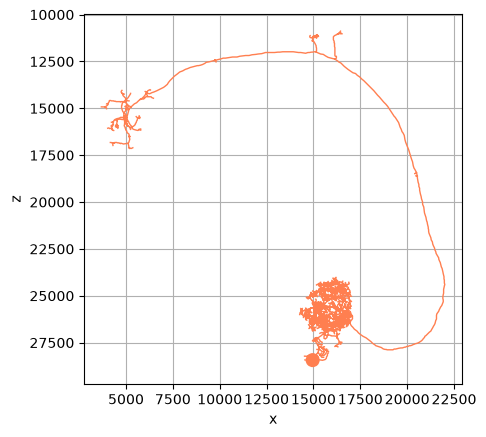

In [4]:
navis.plot2d(n, view=('x', '-z'), color="coral", method='2d')

In [5]:
navis.plot3d(n, color="coral")

INFO  : Using "plotly" backend for 3D plotting. (navis)


In [6]:
# Ask for 3 example neurons
nl = navis.example_neurons(n=3, kind='skeleton')
nl

,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin,file
0,navis.TreeNeuron,DA1_lPN_R,1734350788,4465,2705,599,618,266476.87500,4177.0,8 nanometer,2026-06-18 12:54:51.164530,/opt/miniconda3/envs/neurofly/lib/python3.12/s...,1734350788.swc
1,navis.TreeNeuron,DA1_lPN_R,1734350908,4847,3042,735,761,304332.65625,6.0,8 nanometer,2026-06-18 12:54:51.169080,/opt/miniconda3/envs/neurofly/lib/python3.12/s...,1734350908.swc
2,navis.TreeNeuron,DA1_lPN_R,722817260,4332,3136,633,656,274703.37500,NaN,8 nanometer,2026-06-18 12:54:51.173809,/opt/miniconda3/envs/neurofly/lib/python3.12/s...,722817260.swc


In [7]:
# Access the first neuron in the list
nl[0]

,
type,navis.TreeNeuron
name,DA1_lPN_R
id,1734350788
n_nodes,4465
n_connectors,2705
n_branches,599
n_leafs,618
cable_length,266476.875
soma,4177
units,8 nanometer


In [8]:
# Get the cable length for all neurons in the list
nl.cable_length

array([266476.88, 304332.66, 274703.38], dtype=float32)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='z'>)

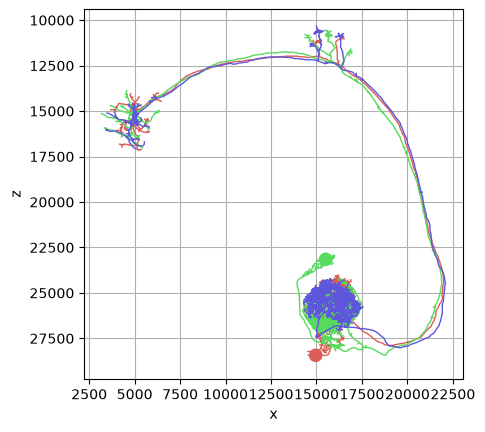

In [9]:
# Generate a plot of our neurons
navis.plot2d(nl, view=('x', '-z'), method='2d')

In [10]:
# Generate a plot of our neurons
navis.plot3d(nl)

# Loading FANC SWC


In [11]:
# Load a single query neuron
query_neuron = navis.read_swc(FANC_DIR / "Skeletons" / "fanc_production_mar2021_left_t1_pmn_skel_72201631671945263.swc")

# Load a whole directory of target neurons into a NeuronList
target_neurons = navis.read_swc(FANC_DIR / "Skeletons" / "*.swc") 

Importing:   0%|          | 0/1647 [00:00<?, ?it/s]

In [12]:
target_neurons

,type,name,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin,file
0,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_74314...,278,None,11,13,1442.984375,None,1 dimensionless,2026-06-18 12:54:54.697408,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_74314...
1,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_72554...,330,None,33,43,1554.967773,None,1 dimensionless,2026-06-18 12:54:54.686325,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_72554...
...,...,...,...,...,...,...,...,...,...,...,...,...
1645,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_74172...,248,None,20,23,1295.930664,None,1 dimensionless,2026-06-18 12:54:56.071030,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_74172...
1646,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_72272...,237,None,25,36,1053.611328,None,1 dimensionless,2026-06-18 12:54:56.071598,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_72272...


In [13]:
# k=5 is the standard number of nearest neighbors used to compute the tangent vector
query_dp = navis.make_dotprops(query_neuron, resample=1000, k=5)
target_dp = navis.make_dotprops(target_neurons, resample=1000, k=5)

Dotprops:   0%|          | 0/1647 [00:00<?, ?it/s]

In [14]:
# Assuming 'scores' is your NBLAST result DataFrame
# Rows = Queries, Columns = Targets

def get_top_n_matches(nblast_scores, n=5):
    """
    Returns a DataFrame showing the top N matches for each query.
    """
    # Get the indices of the top N columns for each row
    # axis=1 sorts across columns
    top_indices = np.argsort(nblast_scores.values, axis=1)[:, ::-1][:, :n]
    
    # Create a new DataFrame for results
    top_matches = pd.DataFrame(index=nblast_scores.index)
    
    for i in range(n):
        # Add the Target ID
        top_matches[f'rank_{i+1}_id'] = nblast_scores.columns[top_indices[:, i]]
        # Add the corresponding NBLAST score
        top_matches[f'rank_{i+1}_score'] = nblast_scores.values[np.arange(nblast_scores.shape[0]), top_indices[:, i]]
        
    return top_matches

In [15]:
scores = navis.nblast(query_dp, target_dp, normalized=True)

print(scores)

Preparing:   0%|          | 0/3 [00:00<?, ?it/s]

NBLASTing:   0%|          | [00:00<?]

target                                36457e7b-31ad-42d8-9300-f95fb41b7a09  \
query                                                                        
cc199e6f-34ef-4eff-8491-b193f966b4ef                             -0.512376   

target                                6f2be12f-949a-448f-98df-09d2bef50785  \
query                                                                        
cc199e6f-34ef-4eff-8491-b193f966b4ef                             -0.650193   

target                                9df5dcf9-6abe-4c6e-94d4-f7e5413e6a7d  \
query                                                                        
cc199e6f-34ef-4eff-8491-b193f966b4ef                               -0.8692   

target                                2e23f711-e3aa-445a-b8df-7e06c8078971  \
query                                                                        
cc199e6f-34ef-4eff-8491-b193f966b4ef                             -0.653434   

target                                d767075e-ec33-4171-aed

In [16]:
# Usage
top_5 = get_top_n_matches(scores, n=5)
# print(top_5.head())
top_5

,rank_1_id,rank_1_score,rank_2_id,rank_2_score,rank_3_id,rank_3_score,rank_4_id,rank_4_score,rank_5_id,rank_5_score
query,,,,,,,,,,
cc199e6f-34ef-4eff-8491-b193f966b4ef,9336f348-fb28-4deb-90b6-d83e55a963b9,1.0,cdd566fb-b854-459e-b474-fc3d58027f2e,0.472863,65501e74-f467-42a4-9993-7976daffd6c2,0.412944,ce35f144-cfa1-4153-b72d-543a76aae295,0.405286,00942c3f-8ce9-4538-b143-bba3b4af1c6d,0.386618


In [17]:
query_neuron

,
type,navis.TreeNeuron
name,fanc_production_mar2021_left_t1_pmn_skel_72201...
n_nodes,154
n_connectors,None
n_branches,16
n_leafs,17
cable_length,714.568237
soma,None
units,1 dimensionless
created_at,2026-06-18 12:54:51.384505


In [18]:
target_neurons[0]

,
type,navis.TreeNeuron
name,fanc_production_mar2021_left_t1_pmn_skel_74314...
n_nodes,278
n_connectors,None
n_branches,11
n_leafs,13
cable_length,1442.984375
soma,None
units,1 dimensionless
created_at,2026-06-18 12:54:54.697408


In [19]:
top_5

,rank_1_id,rank_1_score,rank_2_id,rank_2_score,rank_3_id,rank_3_score,rank_4_id,rank_4_score,rank_5_id,rank_5_score
query,,,,,,,,,,
cc199e6f-34ef-4eff-8491-b193f966b4ef,9336f348-fb28-4deb-90b6-d83e55a963b9,1.0,cdd566fb-b854-459e-b474-fc3d58027f2e,0.472863,65501e74-f467-42a4-9993-7976daffd6c2,0.412944,ce35f144-cfa1-4153-b72d-543a76aae295,0.405286,00942c3f-8ce9-4538-b143-bba3b4af1c6d,0.386618


In [20]:
# Select a query and its top match
query_id = scores.index[0]
best_match_id = top_5.loc[query_id, 'rank_1_id']
next_best_match_id = top_5.loc[query_id, 'rank_2_id']
print("Best Match:",best_match_id)
print("2nd Best Match:",next_best_match_id)

# Get the actual neuron objects
t_neuron = target_neurons.idx[best_match_id]
t_neuron_2 = target_neurons.idx[next_best_match_id]

# Visualize them using navis (Plotly backend)
import navis

navis.plot3d([query_neuron,t_neuron,t_neuron_2], color=["purple",'blue','orange'], alpha=.5)

# plt.show()

Best Match: 9336f348-fb28-4deb-90b6-d83e55a963b9
2nd Best Match: cdd566fb-b854-459e-b474-fc3d58027f2e


# NBLAST on MCFO


In [21]:
print("Initializing headless Fiji environment...")
ij = imagej.init(FIJI_APP, mode="headless", add_legacy=True)
# ij = imagej.init()
# ij.getVersion() returns a java.lang.String; coerce to a Python str.
version = str(ij.getVersion())
print(f"ImageJ version: {version}")
if version.endswith("/Inactive"):
    raise RuntimeError(
        "Legacy ImageJ1 is Inactive in this kernel. Restart the Jupyter "
        "kernel (Kernel -> Restart) and rerun this cell from a clean state."
    )
    
IJ = scyjava.jimport("ij.IJ")

Initializing headless Fiji environment...


[ERROR] Invalid service: class='fiji.plugin.trackmate.TrackMateService', priority=0.0, enabled=true, pluginType=Service
org.scijava.InstantiableException: Class not found: fiji.plugin.trackmate.TrackMateService
	at org.scijava.plugin.PluginInfo.loadClass(PluginInfo.java:290)
	at org.scijava.service.ServiceHelper.findServiceClasses(ServiceHelper.java:368)
	at org.scijava.service.ServiceHelper.<init>(ServiceHelper.java:118)
	at org.scijava.Context.<init>(Context.java:301)
	at org.scijava.Context.<init>(Context.java:252)
	at org.scijava.Context.<init>(Context.java:192)
	at org.scijava.Context.<init>(Context.java:178)
	at net.imagej.ImageJ.<init>(ImageJ.java:75)
Caused by: java.lang.IllegalArgumentException: Cannot load class: fiji.plugin.trackmate.TrackMateService
	at org.scijava.util.Types.iae(Types.java:1033)
	at org.scijava.util.Types.load(Types.java:234)
	at org.scijava.plugin.PluginInfo.loadClass(PluginInfo.java:284)
	... 7 more
Caused by: java.lang.UnsupportedClassVersionError: fiji

ImageJ version: 2.16.0/1.54p


[WARNING] SNT requires Java 21 but this Fiji is running Java 11. SNT commands will not function.


In [22]:
# Launch ImageJ in headless mode using your defined variables

# Path to your target h5j file
# h5j_file_path =  FlyLight_DIR / "SS04748/SS04748-20170324_20_I1-f-20x-ventral_nerve_cord-Split_GAL4-unaligned_stack.h5j"
npz_file_path =  FlyLight_DIR / "SS04748/SS04748-20170324_20_I1.npz"

# Load via Fiji's legacy layer
# imp = IJ.openImage(str(h5j_file_path))

# # Convert the ImagePlus object to a NumPy array
# # Shape will typically be (Channels, Z, Y, X) or (Z, Channels, Y, X)
# img_array = ij.py.from_java(imp)
with np.load(npz_file_path) as data:
    img_array = data['image_data']
    print("Image Shape:", img_array.shape)

Image Shape: (127, 4, 1024, 1024)


In [23]:
import scipy.ndimage as ndimage
from skimage.filters import threshold_otsu

# 1. Isolate your channel (e.g., Channel 0)
# Adjust slice indexing depending on your stack's shape layout
channel_data = img_array[:, 0, :, :]

print(channel_data.shape)

channel_data = np.transpose(channel_data, (1,2,0))

print(channel_data.shape)

# 2. De-noising (Crucial for H.265 compression artifacts)
# filtered_data = ndimage.gaussian_filter(channel_data, sigma=1.0)

# 3. Thresholding to create a binary mask (True = Neuron, False = Background)
thresh = threshold_otsu(channel_data)
binary_mask = channel_data > thresh

(127, 1024, 1024)
(1024, 1024, 127)


In [24]:
# Note: You must provide the true voxel dimensions (microns or nm per pixel) 
# voxel_dims = (0.52, 0.52,1.0) # Example scaling: (x, y, z) sizes in microns

voxel_neuron = navis.VoxelNeuron(channel_data)

# Optional: View the raw voxels to ensure spacing is correct
navis.plot3d([voxel_neuron])

In [ ]:
import numpy as np
import navis
import trimesh
import skeletor
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.measure import marching_cubes

# 1. Standard Thresholding
thresh = threshold_otsu(channel_data)
binary_mask = channel_data > thresh

# 2. Label distinct connected 3D objects
# background=0 treats 0 as the empty space
labeled_mask, num_features = label(binary_mask, background=0, return_num=True)
print(f"Found {num_features} distinct components (including noise).")

# 3. Analyze the components to filter out small noise fragments
props = regionprops(labeled_mask)

# Sort components by size (volume) in descending order
# x.area in 3D gives the total voxel count of that component
sorted_props = sorted(props, key=lambda x: x.area, reverse=True)

# 4. Extract individual masks for the top largest objects
# Let's say you want to isolate the 2 largest distinct neurons
neuron_masks = []
for i in range(min(2, len(sorted_props))): # Adjust '2' to how many main neurons you expect
    neuron_id = sorted_props[i].label
    neuron_size = sorted_props[i].area
    print(f"Neuron {i+1} has an ID of {neuron_id} and size of {neuron_size} voxels.")
    
    # Create a clean binary mask containing ONLY this specific neuron
    individual_mask = (labeled_mask == neuron_id)
    neuron_masks.append(individual_mask)

# 5. Process one of the isolated neurons through your existing skeletonization pipeline
# (Change index to 1 for the second neuron, etc.)
chosen_neuron_mask = neuron_masks[0] 

voxel_dims = (0.52, 0.52, 1.0) 
verts, faces, normals, values = marching_cubes(chosen_neuron_mask, spacing=voxel_dims)
neuron_mesh = trimesh.Trimesh(vertices=verts, faces=faces)
skel_obj = skeletor.skeletonize.by_wavefront(neuron_mesh)
query_neuron = navis.TreeNeuron(skel_obj.swc)

navis.plot3d([query_neuron], color =["blue"])

Found 302 distinct components (including noise).
Neuron 1 has an ID of 75 and size of 7546.0 voxels.
Neuron 2 has an ID of 2 and size of 5288.0 voxels.


Skeletonizing:   0%|          | 0/14318 [00:00<?, ?it/s]

In [26]:
# Convert to dotprops (resample every 1 micron)
query_dp = navis.make_dotprops(query_neuron, resample=1.0, k=5)
target_dp = navis.make_dotprops(target_neurons, resample=1.0, k=5)

# Run NBLAST
scores = navis.nblast(query_dp, target_dp, normalized=True)

Dotprops:   0%|          | 0/1647 [00:00<?, ?it/s]

Preparing:   0%|          | 0/7 [00:00<?, ?it/s]

NBLASTing:   0%|          | [00:00<?]

In [27]:
scores

target,36457e7b-31ad-42d8-9300-f95fb41b7a09,6f2be12f-949a-448f-98df-09d2bef50785,9df5dcf9-6abe-4c6e-94d4-f7e5413e6a7d,2e23f711-e3aa-445a-b8df-7e06c8078971,d767075e-ec33-4171-aed7-d6deb99059a1,8295524b-53ab-432f-8085-db5689d9583f,62fe930e-dadf-4dd2-9cfd-e8227cdd08e1,f0b7a0c5-9132-416a-9128-b2cf34367789,22381954-2a23-4e5e-8164-2281a4e761d9,e62e989a-e6b8-463f-bda1-e255b864a139,...,69ae123e-d463-444c-bfbe-43402d34f132,6a664669-b4ad-4637-af13-9a3edf83ad4a,0d994902-959d-4b92-82e9-67364a4cd91f,361cd586-52c3-4a8b-a155-003ff9e06d63,bdcd87a1-e35b-4eab-bc95-5e912d33390b,e3caf70f-5deb-4c8a-acb8-ea13d5700843,2d9bf4bb-e265-4b87-8a6d-1ffa48928fbe,f262acec-e3f5-4249-bfb8-cd1eeb0102c7,bbaba129-9458-4c77-90e6-9f51930a9d75,8b0a0f24-cd0a-47fb-91b9-aeec27002406
query,,,,,,,,,,,,,,,,,,,,,
dffef91a-1c97-406b-87aa-b36bf193a37f,-0.880581,-0.880257,-0.882183,-0.88149,-0.881417,-0.881774,-0.881732,-0.881616,-0.880591,-0.881282,...,-0.881746,-0.882201,-0.880938,-0.881762,-0.880996,-0.881266,-0.881879,-0.88096,-0.881035,-0.881634


In [28]:
# Usage
top_5 = get_top_n_matches(scores, n=5)
# print(top_5.head())
top_5

,rank_1_id,rank_1_score,rank_2_id,rank_2_score,rank_3_id,rank_3_score,rank_4_id,rank_4_score,rank_5_id,rank_5_score
query,,,,,,,,,,
dffef91a-1c97-406b-87aa-b36bf193a37f,dbe1bf9f-15fc-4046-98f1-ed12570d4561,-0.831239,fe890df0-c843-4588-a83c-aadcf067af5c,-0.839072,a02454cc-6b53-400e-9e67-31b31e672867,-0.842426,5857516b-d10d-4750-b557-426b87a422ec,-0.845398,0e5e90e6-800a-4ce9-9514-afa9e785586e,-0.853291


In [29]:
# Select a query and its top match
query_id = scores.index[0]
best_match_id = top_5.loc[query_id, 'rank_1_id']
next_best_match_id = top_5.loc[query_id, 'rank_2_id']
print("Best Match:",best_match_id)
print("2nd Best Match:",next_best_match_id)

# Get the actual neuron objects
t_neuron = target_neurons.idx[best_match_id]
t_neuron_2 = target_neurons.idx[next_best_match_id]

# Visualize them using navis (Plotly backend)
import navis

navis.plot3d([query_neuron,t_neuron,t_neuron_2], color=['blue','orange', 'purple'], alpha=.5)

# plt.show()

Best Match: dbe1bf9f-15fc-4046-98f1-ed12570d4561
2nd Best Match: fe890df0-c843-4588-a83c-aadcf067af5c
